# Rain Gauge Data Processing
This notebook processes raw precipitation data from three rain gauges (Gazelle Valley, Ziv, and Givat Ram), preparing them for further analysis.

Key steps:
- Load and parse raw CSV data, standardizing timestamps.

- Resample to fixed time intervals (5 or 10 minutes for LAB gauges, auto-detected for IMS).

- Compute rain intensity (mm/hr).

- For LAB gauges, set all rainfall values in July and August to zero (to remove false dew/heat-related readings).

- Export cleaned data to CSV files with a _processed suffix.



# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from collections import Counter
import os


# Functions

In [2]:
def process_lab_gauge_precipitation_data(file_path, interval_minutes=10):
    """
    Processes LAB gauge precipitation data, removes summer false rainfall (e.g., dew in July–August).

    Parameters:
    - file_path (str): Path to the CSV file containing the data.
    - interval_minutes (int): Resampling interval in minutes (default is 10). Only 5 or 10 are allowed.

    Returns:
    - pd.DataFrame: DataFrame with datetime, rain, cumulative rain, and intensity.
    """

    if interval_minutes not in [5, 10]:
        raise ValueError("Interval must be either 5 or 10 minutes.")

    # Load and set datetime index
    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df.set_index('Date Time', inplace=True)

    # Set default rain value
    df['rain_mm'] = 0.1

    # Resample
    interval = pd.Timedelta(minutes=interval_minutes)
    df_resampled = df.resample(interval).sum()

    # Reset index column
    df_resampled['date_time'] = pd.to_datetime(df_resampled.index.round(interval))

    # ✅ Set rain to 0 during July and August
    df_resampled.loc[df_resampled['date_time'].dt.month.isin([7, 8]), 'rain_mm'] = 0.0

    # Calculate cumulative and intensity
#     df_resampled['cumulative_rain_mm'] = df_resampled['rain_mm'].cumsum()
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (60 / interval_minutes)

    # Reorder and clean
    df_resampled = df_resampled[['date_time',  'rain_mm', 'rain_intens_10min_mm_hr']]
    df_resampled.reset_index(drop=True, inplace=True)

    return df_resampled



def process_ims_gauge_precipitation_data(file_path):
    """
    Processes IMS gauge precipitation data. Infers time step, fills gaps with 0.
    Parameters:
    - file_path (str): Path to CSV file.
    Returns:
    - pd.DataFrame with: 'date_time', 'cumulative_rain_mm', 'rain_mm', 'rain_intens_10min_mm_hr'.
    """
    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d/%m/%Y %H:%M', errors='coerce')
    df.dropna(subset=['Date Time', 'Rain (mm)'], inplace=True)
    df.sort_values('Date Time', inplace=True)
    df.set_index('Date Time', inplace=True)
    df.rename(columns={'Rain (mm)': 'rain_mm'}, inplace=True)

    diffs = df.index.to_series().diff().dropna().dt.total_seconds()
    counter = Counter(diffs.round())
    most_common_step = int(counter.most_common(1)[0][0])
    freq_str = f'{most_common_step // 60}T'
    print("⏱️ Givat Ram Time step breakdown:", counter)
    print(f"✅ Using resample interval: {freq_str}")

    df_resampled = df.resample(freq_str).sum().fillna(0.0)
    df_resampled.reset_index(inplace=True)
    df_resampled.rename(columns={'Date Time': 'date_time'}, inplace=True)
#     df_resampled['cumulative_rain_mm'] = df_resampled['rain_mm'].cumsum()
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (3600 / most_common_step)

    return df_resampled[['date_time', 'rain_mm', 'rain_intens_10min_mm_hr']]


def plot_rain_intensity(rain_dfs, start_date, end_date):
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')
    filtered_dfs = [df[(df['date_time'] >= start_date) & (df['date_time'] <= end_date)] for df in rain_dfs]

    plt.figure(figsize=(12, 6))
    for i, df in enumerate(filtered_dfs):
        plt.plot(df['date_time'], df['rain_intens_10min_mm_hr'], label=f'{rain_dfs[i].name}')

    plt.title('Rain Intensity (mm/hr)')
    plt.xlabel('Date Time')
    plt.ylabel('Rain Intensity (mm/hr)')
    plt.legend()
    plt.grid(True)

    num_ticks = 10
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['date_time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y %H'))
    plt.ylim(0)
    plt.xlim(filtered_dfs[0]['date_time'].iloc[0], end_date)
    plt.tight_layout()
    plt.show()


def plot_cumulative_rain(rain_dfs, start_date, end_date):
    """
    Plots cumulative rain (mm) for multiple DataFrames within a specified date range.
    Cumulative rain is calculated inside this function.

    Parameters:
    - rain_dfs (list): List of DataFrames with 'date_time' and 'rain_mm' columns.
    - start_date (str): Start date (format: '%d/%m/%Y %H:%M').
    - end_date (str): End date (format: '%d/%m/%Y %H:%M').
    """
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')

    filtered_dfs = []
    for df in rain_dfs:
        filtered = df[(df['date_time'] >= start_date) & (df['date_time'] <= end_date)].copy()
        filtered['cumulative_rain_mm'] = filtered['rain_mm'].cumsum()
        filtered_dfs.append(filtered)

    plt.figure(figsize=(12, 6))
    for i, df in enumerate(filtered_dfs):
        plt.plot(df['date_time'], df['cumulative_rain_mm'], label=f'{rain_dfs[i].name}')

    plt.title('Cumulative Rain (mm)')
    plt.xlabel('Date Time')
    plt.ylabel('Cumulative Rain (mm)')
    plt.legend()
    plt.grid(True)

    num_ticks = 10
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['date_time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y %H'))
    plt.ylim(0)
    plt.xlim(filtered_dfs[0]['date_time'].iloc[0], end_date)
    plt.tight_layout()
    plt.show()


def save_processed_rain(df, original_path):
    """
    Saves processed rain DataFrame next to original file with '_processed' suffix.
    """
    directory, original_filename = os.path.split(original_path)
    name, ext = os.path.splitext(original_filename)
    output_filename = f"{name}_processed.csv"
    output_path = os.path.join(directory, output_filename)
    df.to_csv(output_path, index=False)
    print(f"✅ Saved processed file to:\n{output_path}")

    

In [3]:
def process_ims_gauge_precipitation_data(file_path):
    from collections import Counter

    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d/%m/%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date Time', 'Rain (mm)'])
    df = df[~df['Date Time'].duplicated(keep='first')]
    df['Date Time'] = df['Date Time'].dt.tz_localize(None)
    df.set_index('Date Time', inplace=True)
    df.rename(columns={'Rain (mm)': 'rain_mm'}, inplace=True)

    # Infer time step
    diffs = df.index.to_series().diff().dropna().dt.total_seconds()
    counter = Counter(diffs.round())
    most_common_step = int(counter.most_common(1)[0][0])
    freq_str = f'{most_common_step // 60}T'
    print("⏱️ Givat Ram Time step breakdown:", counter)
    print(f"✅ Using resample interval: {freq_str}")

    # Resample
    df_resampled = df.resample(freq_str).sum().fillna(0.0)
    df_resampled.index = df_resampled.index.tz_localize(None)
    df_resampled.index.name = 'date_time'

    # Calculate intensity
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (3600 / most_common_step)

    # Final clean
    df_resampled = df_resampled.reset_index()
    df_resampled = df_resampled[['date_time', 'rain_mm', 'rain_intens_10min_mm_hr']]
    df_resampled = df_resampled.dropna(subset=['date_time'])
    df_resampled = df_resampled[~df_resampled['date_time'].duplicated(keep='first')]
    df_resampled = df_resampled.sort_values('date_time')

    return df_resampled


# Main

In [5]:
# Example usage:
gv_file_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\gazelle_valley\20230921_20241117.csv"
ziv_file_path = r'D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\ziv\20230921_20241117.csv'
ram_file_path = r'D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20231030_20251117.csv'

gv_rain_df = process_lab_gauge_precipitation_data(gv_file_path)
ziv_rain_df = process_lab_gauge_precipitation_data(ziv_file_path)
ram_rain_df = process_ims_gauge_precipitation_data(ram_file_path)

gv_rain_df.name = 'gazelle_valley'
ziv_rain_df.name = 'ziv'
ram_rain_df.name = 'ram'

# Save processed rain data to CSV files
save_processed_rain(gv_rain_df, gv_file_path)
save_processed_rain(ziv_rain_df, ziv_file_path)
save_processed_rain(ram_rain_df, ram_file_path)

⏱️ Givat Ram Time step breakdown: Counter({600.0: 107838, 1200.0: 12, 1800.0: 6, 2400.0: 2, 3000.0: 1})
✅ Using resample interval: 10T
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\gazelle_valley\20230921_20241117_processed.csv
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\ziv\20230921_20241117_processed.csv
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20231030_20251117_processed.csv


# Plot

### Is it dew in the summer?

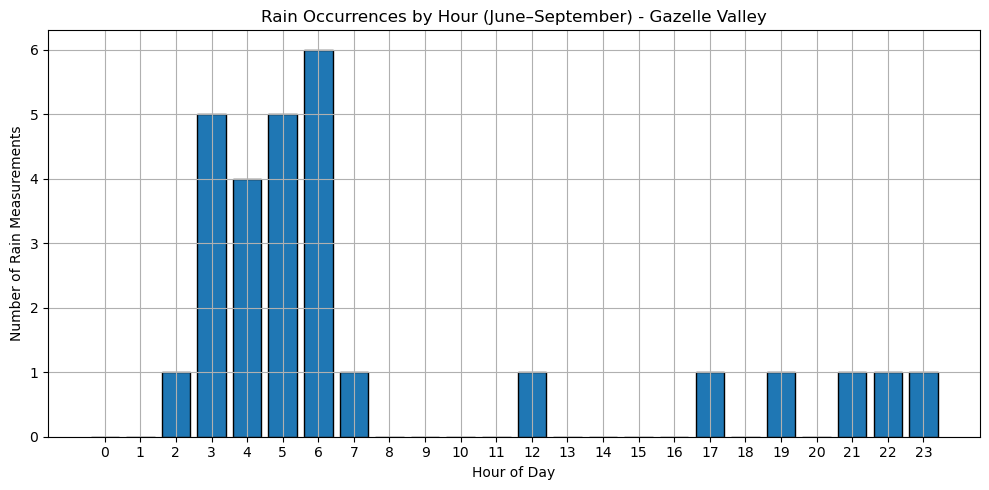

In [6]:
def plot_summer_hourly_rain_histogram(rain_df, station_name='Station'):
    """
    Plots histogram of rain measurements by hour of day during summer months (June–September).

    Parameters:
    - rain_df (pd.DataFrame): Rain data with 'date_time' and 'rain_mm' columns.
    - station_name (str): Name for labeling the station in the plot.
    """
    # Filter for summer months (June=6 to September=9)
    summer_df = rain_df[rain_df['date_time'].dt.month.isin([6, 7, 8, 9])]

#     summer_df = rain_df[rain_df['date_time'].dt.month.isin([12,1,2])]

    # Keep only rows with positive rain
    summer_df = summer_df[summer_df['rain_mm'] > 0]

    # Extract hour from timestamp
    summer_df['hour'] = summer_df['date_time'].dt.hour

    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.hist(summer_df['hour'], bins=range(25), edgecolor='black', align='left', rwidth=0.8)
    plt.xticks(range(24))
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rain Measurements')
    plt.title(f'Rain Occurrences by Hour (June–September) - {station_name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_summer_hourly_rain_histogram(gv_rain_df, station_name='Gazelle Valley')


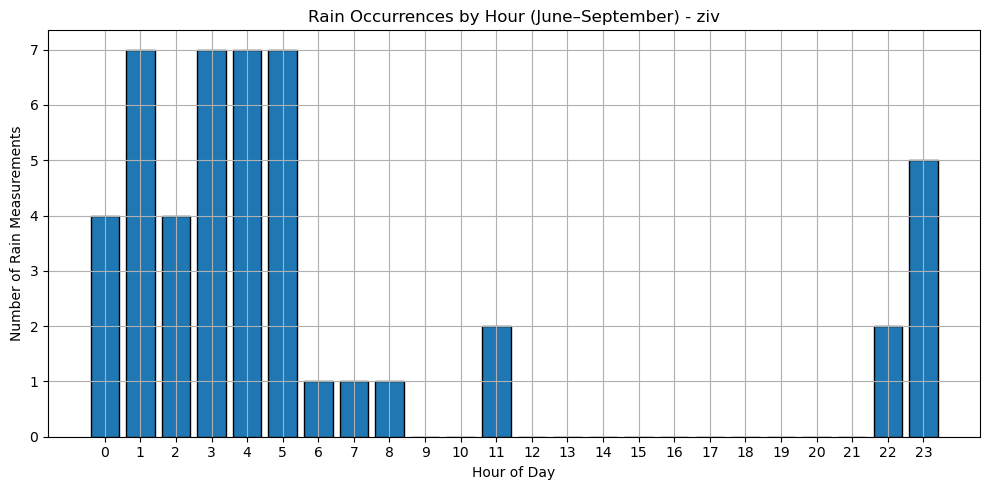

In [7]:
plot_summer_hourly_rain_histogram(ziv_rain_df, station_name='ziv')


In [8]:
ram_rain_df

,date_time,rain_mm,rain_intens_10min_mm_hr
0,2023-10-30 10:00:00,0.0,0.0
1,2023-10-30 10:10:00,0.0,0.0
2,2023-10-30 10:20:00,0.0,0.0
3,2023-10-30 10:30:00,0.0,0.0
4,2023-10-30 10:40:00,0.0,0.0
...,...,...,...
107889,2025-11-17 15:30:00,0.0,0.0
107890,2025-11-17 15:40:00,0.0,0.0
107891,2025-11-17 15:50:00,0.0,0.0
107892,2025-11-17 16:00:00,0.0,0.0


## Extract rain events - by ram station

In [9]:
def identify_rain_events(rain_df, rain_col='rain_mm', time_col='date_time',
                         min_dry_gap_hours=6, min_event_total_mm=5):
    """
    Identifies rainfall events using dry-gap separation and filters by total event rain.

    Parameters:
    - rain_df: DataFrame with datetime index and rain values in mm.
    - rain_col: Column with rain data.
    - time_col: Column with datetime if not already index.
    - min_dry_gap_hours: Minimum dry period (in hours) to separate events.
    - min_event_total_mm: Minimum total rain in event to consider as valid.

    Returns:
    - DataFrame with: rain_event_start, rain_event_end, total_rain_mm
    """
    df = rain_df.copy()

    # Ensure datetime index
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col], dayfirst=True, errors='coerce')
        df.set_index(time_col, inplace=True)

    df = df.sort_index()

    # Keep only rows where it rained
    rain_only = df[df[rain_col] > 0].copy()
    if rain_only.empty:
        return pd.DataFrame(columns=['rain_event_start', 'rain_event_end', 'total_rain_mm'])

    # Time difference between rain rows
    rain_only['time_diff_hr'] = rain_only.index.to_series().diff().dt.total_seconds().div(3600).fillna(0)

    # Start new event if time gap exceeds dry period
    rain_only['new_event'] = rain_only['time_diff_hr'] > min_dry_gap_hours
    rain_only['event_group'] = rain_only['new_event'].cumsum()

    # Group by event group (internal use only)
    grouped = rain_only.groupby('event_group')
    events = []
    for _, group in grouped:
        total = group[rain_col].sum()
        if total >= min_event_total_mm:
            events.append({
                'rain_event_start': group.index.min(),
                'rain_event_end': group.index.max(),
                'total_rain_mm': total
            })

    return pd.DataFrame(events).reset_index(drop=True)


In [10]:
# Load rain data
ram_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20231030_20250410_processed.csv"
ram_rain = pd.read_csv(ram_path, parse_dates=['date_time'])

# Identify rain events
rain_events_df = identify_rain_events(
    rain_df=ram_rain,
    rain_col='rain_mm',
    min_dry_gap_hours=6,
    min_event_total_mm=0.5
)

# Save to CSV
output_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\rain_events_givat_ram.csv"
rain_events_df.to_csv(output_path, index=False)
print(f"✅ Saved rain events to:\n{output_path}")


✅ Saved rain events to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\rain_events_givat_ram.csv


# Plot

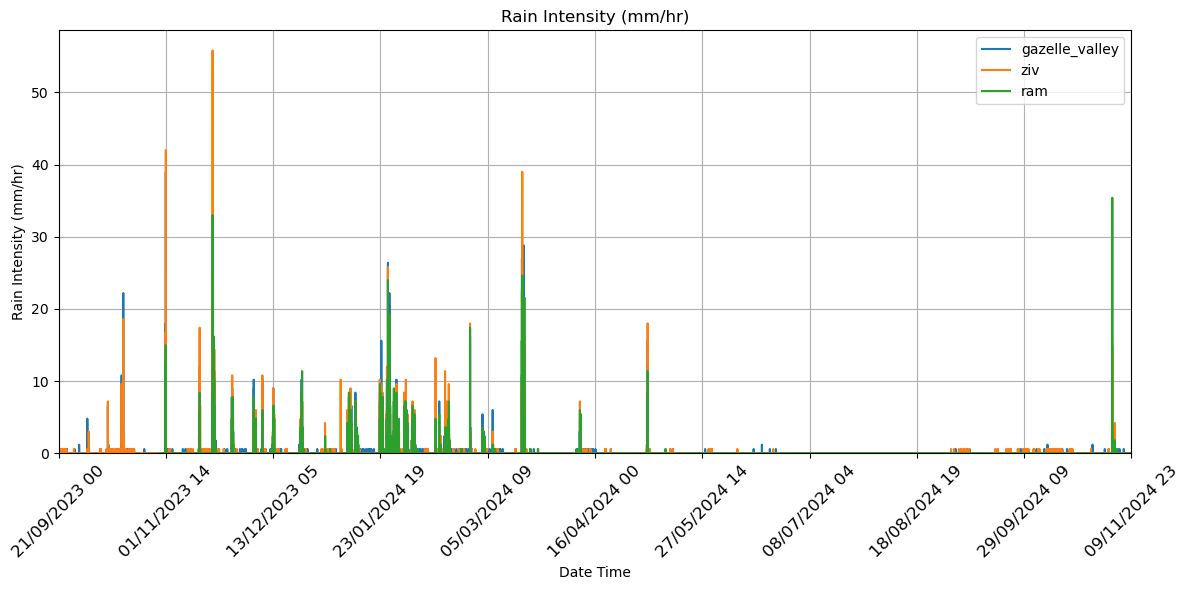

In [11]:
plot_rain_intensity([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

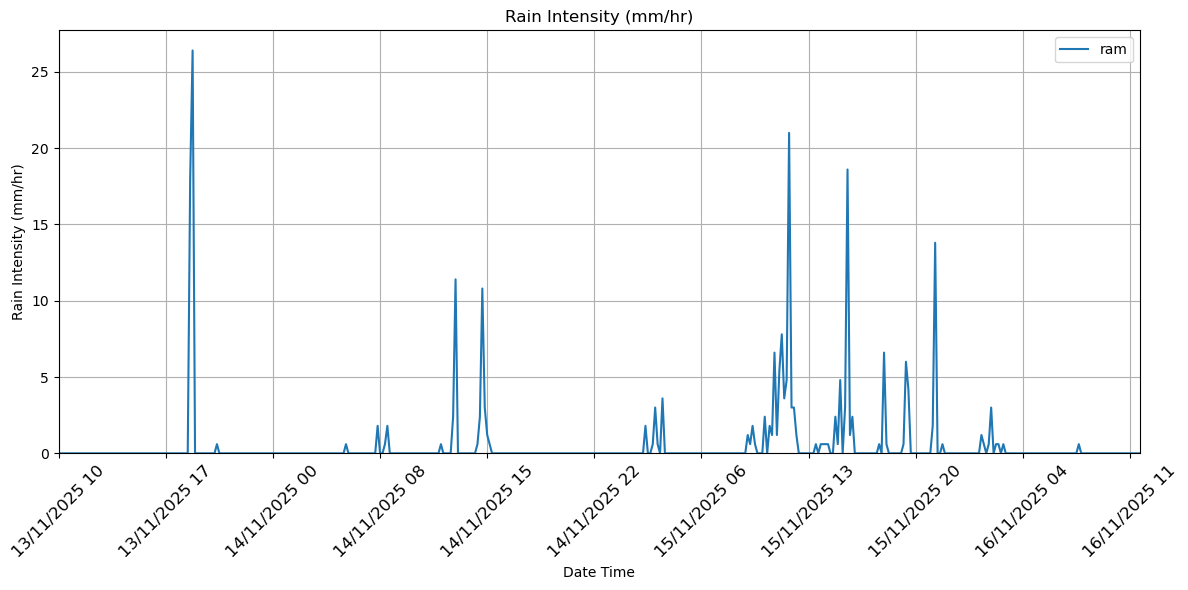

In [12]:
plot_rain_intensity([ram_rain_df], '13/11/2025 10:00', '16/11/2025 12:00')

## Cumulative Rain

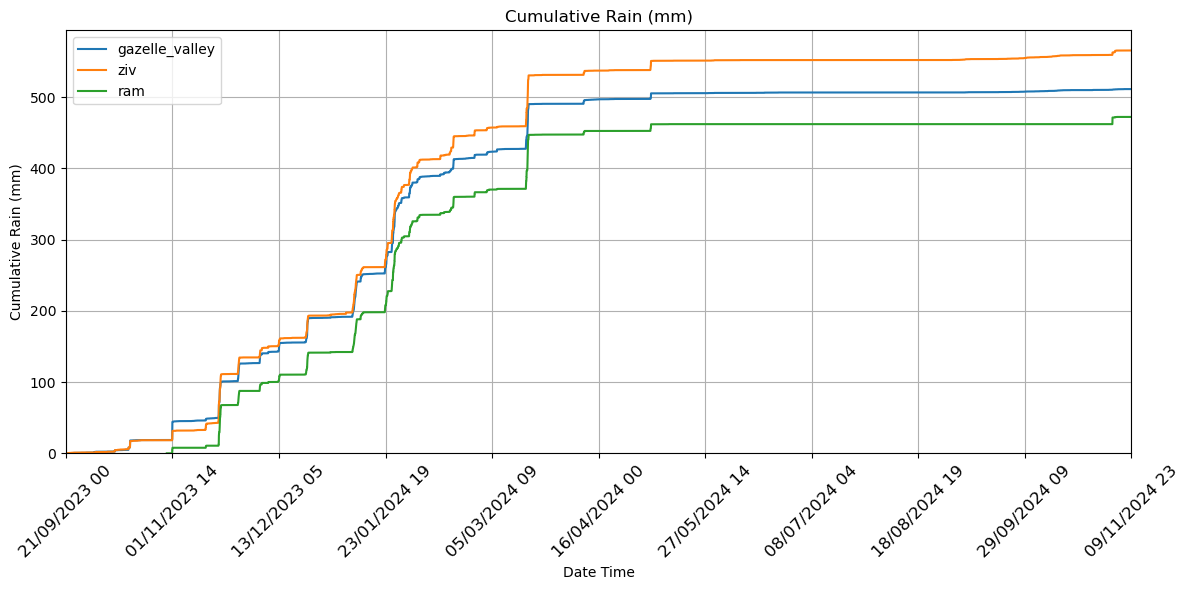

In [13]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

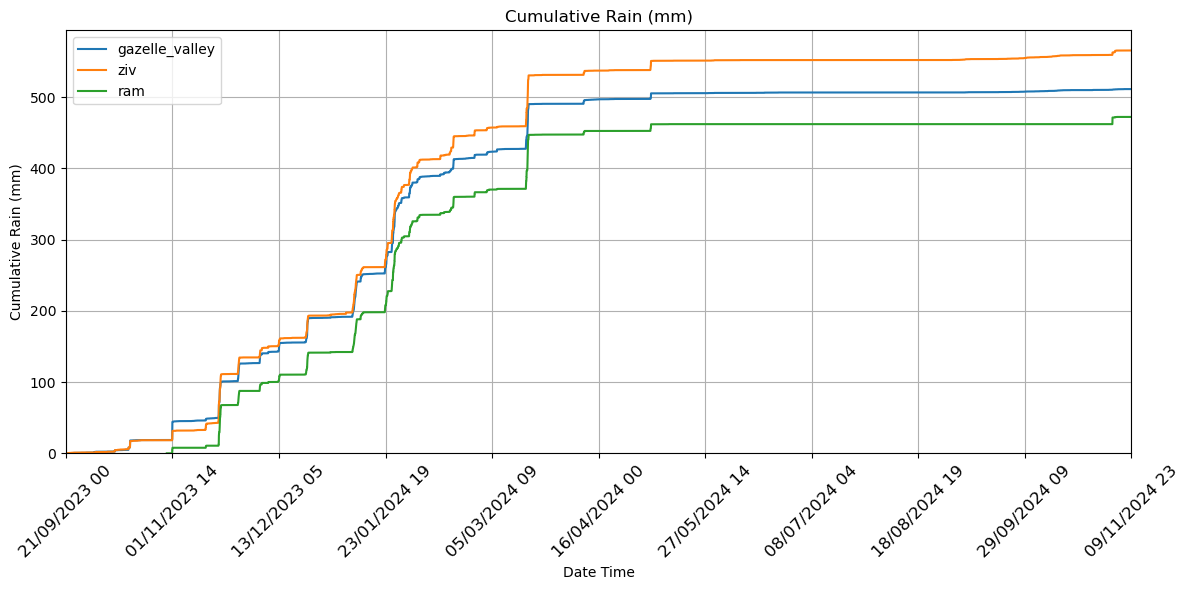

In [14]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

In [15]:
ram_rain_df

,date_time,rain_mm,rain_intens_10min_mm_hr
0,2023-10-30 10:00:00,0.0,0.0
1,2023-10-30 10:10:00,0.0,0.0
2,2023-10-30 10:20:00,0.0,0.0
3,2023-10-30 10:30:00,0.0,0.0
4,2023-10-30 10:40:00,0.0,0.0
...,...,...,...
107889,2025-11-17 15:30:00,0.0,0.0
107890,2025-11-17 15:40:00,0.0,0.0
107891,2025-11-17 15:50:00,0.0,0.0
107892,2025-11-17 16:00:00,0.0,0.0


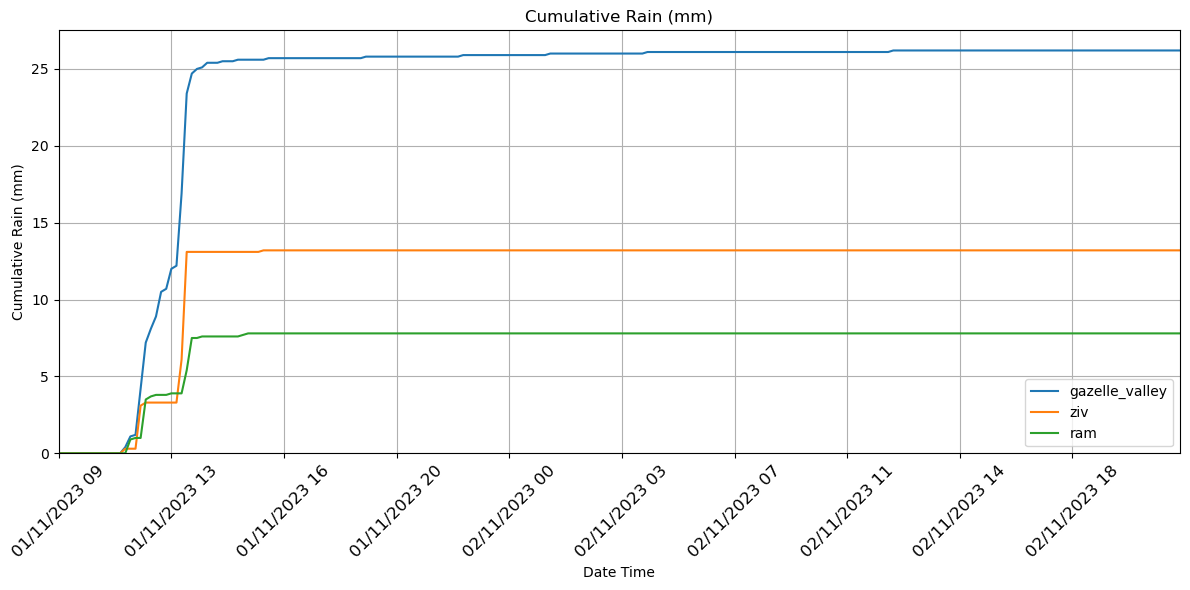

In [16]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '01/11/2023 09:30', '02/11/2023 22:00')